<a href="https://colab.research.google.com/github/PX2145-2025/week-4-b-Callum-mason68/blob/main/curvefit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

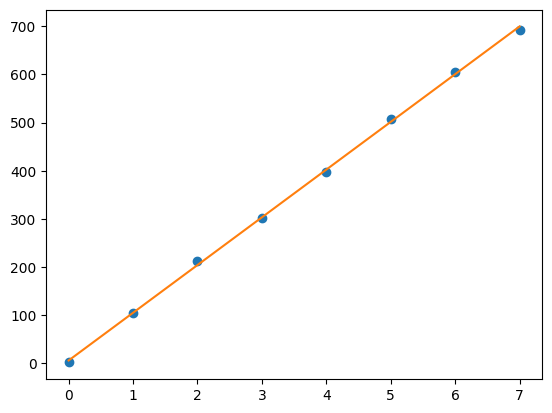

In [ ]:
x_data = np.array([ 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0 ])
y_data = np.array([ 2, 104, 212, 302, 398, 507, 606, 692 ])

def linear_fit(x,m,c):
  return m*x + c
data = np.linspace(min(x_data), max(x_data), 100)
p_guess = [100,1]
popt, pcov = curve_fit(linear_fit, x_data, y_data, p_guess)
plt.plot(x_data,y_data, 'o')
plt.plot(data, linear_fit(data, *popt))

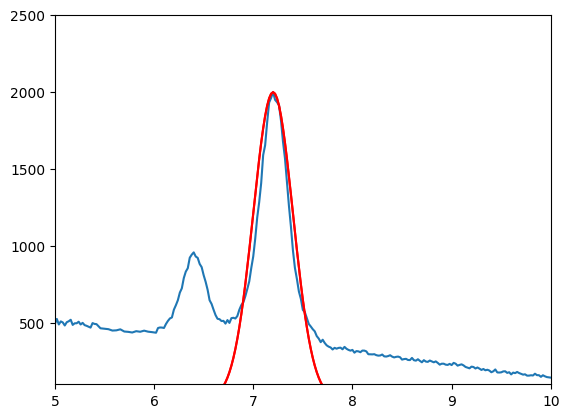

In [ ]:
from math import sqrt
! wget -q https://raw.githubusercontent.com/PX2134/data/master/week4/XRD_data_Mo_anode.csv
data = np.loadtxt("XRD_data_Mo_anode.csv", skiprows = 2, delimiter = ',')# unpack = True)
x_data = data[:, 0]
y_data = data[:, 1]
plt.plot(x_data, y_data)

angles_selected=x_data[(x_data>=6) & (x_data<=7)]
counts_selected=y_data[(y_data>=800) & (y_data<=2100)]

def Gau(x, I, mu, sigma):
  return(I*np.exp(-(x-mu)**2/(2*sigma**2))/(sigma*np.sqrt(2*np.pi)))
plt.ylim(100,2500)
plt.xlim(5,10)
p_init = np.array([1000,7.2,0.2])
plt.plot(x_data, Gau(x_data, p_init[0], p_init[1], p_init[2]), 'r', label='Guess')

def Gau_background(x, intensity, mu, sigma, bckg):
  return Gau(x, intensity, mu, sigma) + bckg
bckg_guess = np.array([1000,7.2,0.2,3])
plt.plot(x_data, Gau_background(x_data, bckg_guess [0], bckg_guess [1], bckg_guess [2], bckg_guess [3]), 'r', label='Guess')